# **8. EXTRA: Regresión simbólica con PySR.**

Temas selectos de aprendizaje de máquina \
Ana Luisa Llamas Martinez

In [1]:
from pysr import PySRRegressor
import numpy as np
import matplotlib.pyplot as plt

## 8.2 Generación de los datos.

In [2]:
np.random.seed(123)

n = 200

x = np.random.uniform(-3, 3, n)

epsilon = np.random.normal(
    loc=0,
    scale=0.3,
    size=n
)

y = x**2 + 2*np.sin(x) + epsilon

## 8.3 Visualización.

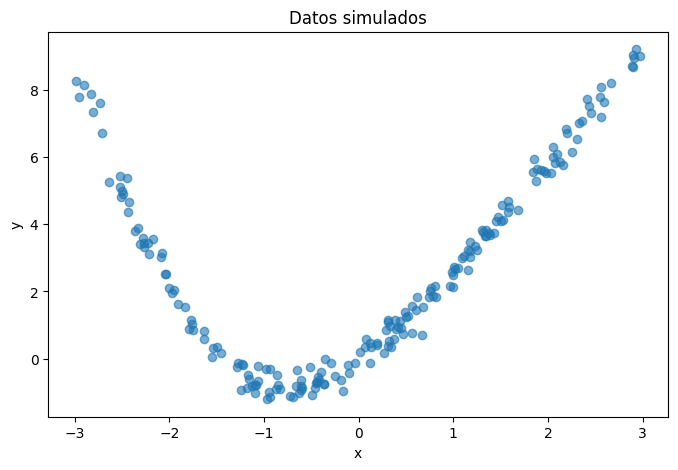

In [3]:
plt.figure(figsize=(8, 5))

plt.scatter(
    x,
    y,
    alpha=0.6
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Datos simulados")

plt.show()

## 8.4 Preparación de los datos.

In [4]:
x.shape

(200,)

In [5]:
X = x.reshape(-1,1)
X.shape

(200, 1)

## 8.5 Modelo de regresión simbólica.

In [6]:
model = PySRRegressor(niterations=20, 
                      binary_operators = ["+", "-", "*"],
                      unary_operators= ["sin"],
                      verbosity = 1)

## 8.6 Ajuste del modelo.

In [7]:
model.fit(X,y)

Compiling Julia backend...


PySRRegressor.equations_ = [
	    pick         score                                           equation  \
	0         0.000000e+00                                          2.5612218   
	1         6.796294e-01                                            x0 * x0   
	2         5.797352e-01                             x0 * (x0 - -0.7610193)   
	3         1.261883e-01                                sin(x0) + (x0 * x0)   
	4   >>>>  9.839476e-01                  (x0 * x0) + (sin(x0) * 1.9895884)   
	5         7.986337e-03  ((sin(x0) * 1.9915229) + -0.036265958) + (x0 *...   
	6         2.095558e-03  (x0 * x0) + ((sin(x0 + 3.1277988) * -1.9923631...   
	7         2.288048e-04  ((x0 - -0.0071003637) * x0) + ((sin(x0 + 3.127...   
	8         4.688792e-03  ((sin(sin(x0)) * x0) * -1.9029919) + ((sin(x0 ...   
	9         6.216723e-08  ((sin(x0 + 1.9538053) * -5.3158827) + (((sin(s...   
	10        6.153990e-04  ((sin(x0 + 1.9555308) * -5.3007374) + (((sin(s...   
	11        4.409472e-03  ((x0 + 0.0

## 8.8 Expresión seleccionada.

In [8]:
model.sympy()

x0*x0 + sin(x0)*1.9895884

## 8.9 Visualización del ajuste.

In [9]:
X_grid = np.linspace(-3,3, 500)
X_grid = X_grid.reshape(-1,1)

y_pred = model.predict(X_grid)

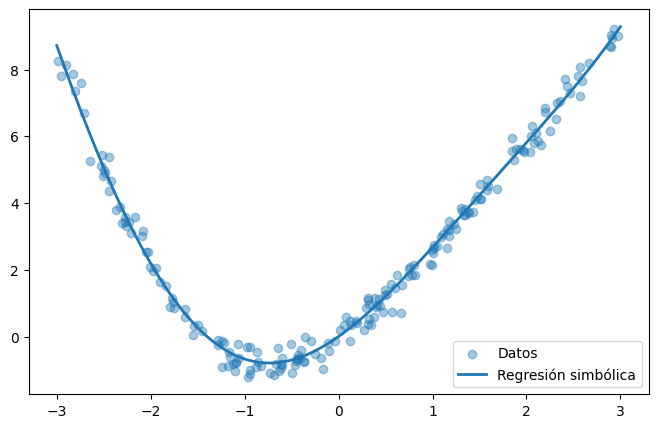

In [10]:
plt.figure(figsize=(8,5))

plt.scatter(x,y,alpha = 0.4,  label = "Datos")

plt.plot(X_grid, y_pred, linewidth=2, label = "Regresión simbólica")

plt.legend()
plt.show()

## 8.11 Ejercicios.

**8.11.1 Ejercicio 1: Datos simulados.** Genera ahora un nuevo conjunto de datos utilizando

$$
y = 3x^{2} - 2x + 5 + \epsilon, \epsilon \sim N(0, 0.5^{2})
$$

1) Genera 200 observaciones con $x \in [-3,3]$.

In [11]:
n1 = 200

x1 = np.random.uniform(-3, 3, n1)

epsilon1 = np.random.normal(
    loc=0,
    scale=0.5**2,
    size=n1
)

y1 = (3 * x1**2) - (2 * x1) + 5 + epsilon

2) Ajusta un modelo de regresión simbólica utilizando solamente

$$
+ , -, \times.
$$

In [12]:
X1 = x1.reshape(-1,1)
X1.shape

model1 = PySRRegressor(niterations=20, 
                      binary_operators = ["+", "-", "*"],
                      verbosity = 1)

3) Observa las ecuaciones encontradas.

In [13]:
model1.fit(X1,y1)

PySRRegressor.equations_ = [
	    pick         score                                           equation  \
	0         0.000000e+00                                          13.542141   
	1         4.674884e-02                                     13.791496 - x0   
	2         4.938430e-01                              (x0 * x0) * 3.7843726   
	3         3.834416e-01              ((x0 + -0.51497114) * 3.9496157) * x0   
	4   >>>>  2.459617e+00  ((x0 + -0.6794082) * (3.0047557 * x0)) + 4.959...   
	5         1.306047e-07  (x0 * (-2.041453 - ((x0 * -2.0047555) - x0))) ...   
	6         5.809407e-04  (((x0 * ((x0 * 0.0023701421) - -3.0046163)) + ...   
	7         1.307566e-07  ((-2.0537255 - (x0 * ((x0 + -3.0046115) - (x0 ...   
	8         6.440640e-04  ((-2.0523772 - (x0 * (-3.0046332 - (x0 * ((x0 ...   
	9         1.636567e-06  ((-2.0523217 - (x0 * (-3.0046213 - (x0 * ((x0 ...   
	10        1.880941e-03  (x0 * (-2.0129921 - (x0 * ((-3.005071 - (x0 * ...   
	11        2.915567e-05  (((((((x0 

4) Compara la expresión seleccionada con

$$
3x^{2} - 2x + 5.
$$

In [14]:
model1.sympy()

(x0 - 0.6794082)*3.0047557*x0 + 4.9594755

5) Grafica los datos y la función encontrada.

In [15]:
X_grid1 = np.linspace(-3,3, 500)
X_grid1 = X_grid1.reshape(-1,1)

y_pred1 = model1.predict(X_grid1)

y_true1 = (3 * X_grid1**2) - (2 * X_grid1) + 5 

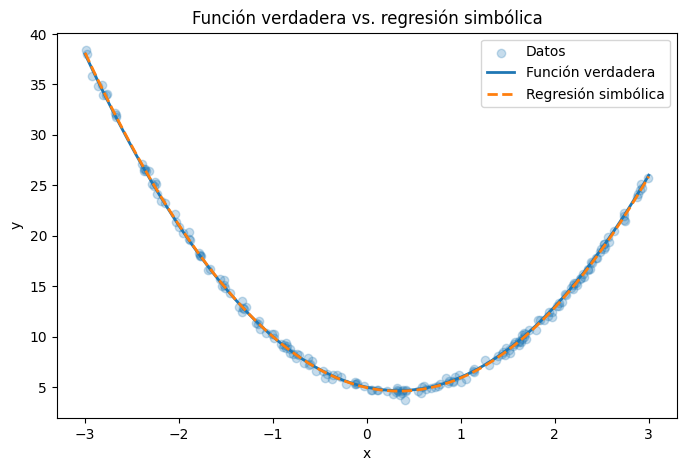

In [16]:
plt.figure(figsize=(8, 5))

plt.scatter(
    x1,
    y1,
    alpha=0.25,
    label="Datos"
)

plt.plot(
    X_grid1,
    y_true1,
    linewidth=2,
    label="Función verdadera"
)

plt.plot(
    X_grid1,
    y_pred1,
    linestyle="--",
    linewidth=2,
    label="Regresión simbólica"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Función verdadera vs. regresión simbólica")

plt.legend()

plt.show()

6) ¿Logra PySR recuperar aproximadamente la estructura de la función original?

Sí.
7) ¿Qué ocurre con los coeficientes debido a la presencia de ruido?

Son casi parecidos.

**Ejercicio 2: Regresión simbólica con los datos de “Wage”.**

En los ejemplos anteriores trabajamos con el conjunto de datos Wage para estudiar la relación entre la edad (age) y el salario (wage) utilizando diferentes técnicas de regresión no lineal.

Ahora utilizaremos regresión simbólica sobre los mismos datos.

A diferencia del ejemplo anterior, en este caso no conocemos la función que generó los datos.

1. Preparación de los datos

Utiliza age como variable predictora y wage como variable respuesta:

$$
wage = f(age)
$$

Prepara los datos en el formato requerido por PySR.



In [24]:
from ISLP import load_data
Wage = load_data("Wage")

age = Wage["age"]
wage = Wage["wage"]

X2 = np.column_stack([
    Wage["age"]
])

Y2 = np.column_stack([
    Wage["wage"]
])

2. Regresión simbólica

Construye un modelo PySRRegressor utilizando inicialmente las operaciones

$$
+, -, \times, /.
$$

No utilizar sin en este primer modelo.

Ajustar el modelo y examinar las expresiones encontradas.

Observen las diferentes expresiones encontradas.

In [25]:
model2 = PySRRegressor(niterations=20, 
                      binary_operators = ["+", "-", "*", "/"],
                      verbosity = 1)

model2.fit(X2, Y2)

PySRRegressor.equations_ = [
	   pick     score                                           equation  \
	0        0.000000                                          111.68374   
	1        0.016116                                     x0 - -69.31651   
	2  >>>>  0.017742                       142.45236 - (1206.3046 / x0)   
	3        0.009420                225.85571 - ((2793.9126 / x0) + x0)   
	4        0.000002  ((((x0 / -0.79300755) / 2793.9126) + 225.85571...   
	
	        loss  complexity  
	0  1740.6953           1  
	1  1685.4850           3  
	2  1626.7244           5  
	3  1596.3641           7  
	4  1596.3452          13  
]

In [19]:
model2.sympy()

143.68631 - 1262.2329/x0

- ¿Cuál tiene el menor error?
- ¿Cuál es la más sencilla?
- ¿Qué ocurre con la complejidad conforme disminuye el error?
- ¿Qué expresión elegirías considerando conjuntamente error e interpretabilidad?


3. Visualización

Graficar los datos originales y superponer la curva correspondiente a la regresión simbólica.

In [20]:
age_grid = np.linspace(Wage['age'].min(), Wage['age'].max(), 200)
age_grid = age_grid.reshape(-1,1)

y_pred2 = model2.predict(age_grid)

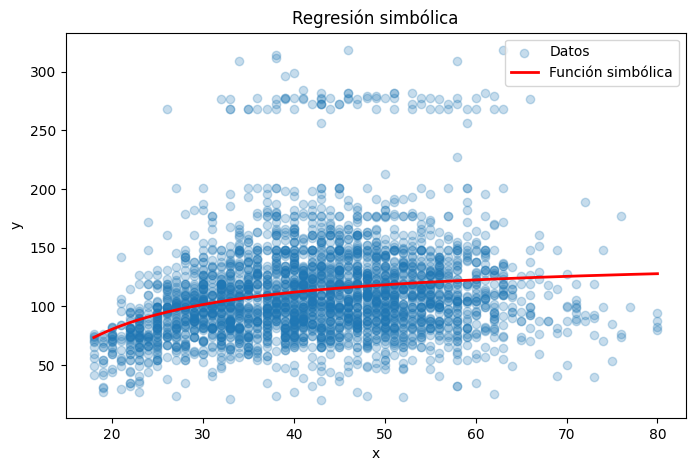

In [21]:
plt.figure(figsize=(8, 5))

plt.scatter(
    age,
    wage,
    alpha=0.25,
    label="Datos"
)

plt.plot(
    age_grid,
    y_pred2,
    linewidth=2,
    color = "red",
    label="Función simbólica"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Regresión simbólica")

plt.legend()

plt.show()

4. Comparación con modelos anteriores

En prácticas anteriores modelamos estos mismos datos utilizando métodos como regresión polinomial y splines.

Compara cualitativamente la regresión simbólica con alguno de esos modelos.

In [22]:
model3 = PySRRegressor(niterations=20, 
                      binary_operators = ["+", "-", "*", "/"],
                      unary_operators= ["sin", "cos"],
                      verbosity = 1)

model3.fit(X2, Y2)


PySRRegressor.equations_ = [
	   pick     score                                           equation  \
	0        0.000000                                         111.717575   
	1        0.016114                                    x0 - -69.211754   
	2  >>>>  0.017953                      (-1411.5933 / x0) + 147.33221   
	3        0.008373               ((-2925.2278 / x0) + 228.69475) - x0   
	4        0.000059  (((-0.122405075 + (x0 + ((x0 + x0) / -2.107908...   
	
	        loss  complexity  
	0  1740.6956           1  
	1  1685.4901           3  
	2  1626.0440           5  
	3  1599.0416           7  
	4  1598.0980          17  
]

In [23]:
model3.sympy()

147.33221 - 1411.5933/x0

- ¿La regresión simbólica captura adecuadamente la relación entre edad y salario?

    Sí.
- ¿La expresión obtenida es fácil de interpretar?

    No tanto.
- ¿Qué ventaja tiene disponer de una expresión matemática explícita?

    Puede ayudar a modelar algún fenómeno.
- ¿Qué ventajas tenían los splines frente a la expresión encontrada?

    Que son más fáciles de interpretar.
5. Modificando el espacio de búsqueda

Hasta ahora decidimos qué operaciones podía utilizar el algoritmo.

Prueba una segunda configuración modificando las operaciones o funciones disponibles y vuelve a ajustar el modelo.

Comparen las ecuaciones obtenidas con las del primer modelo.

In [28]:
model4 = PySRRegressor(niterations=20, 
                      binary_operators = ["+", "-", "*", "/"],
                      unary_operators= ["sin", "cos", "tan"],
                      verbosity = 1)

model4.fit(X2, Y2)

PySRRegressor.equations_ = [
	   pick     score                                           equation  \
	0        0.000000                                          111.60473   
	1        0.016117                                      x0 + 69.21584   
	2  >>>>  0.016815                      (-1312.5099 / x0) - -147.3823   
	3        0.009350                (-2559.628 / x0) + (221.22617 - x0)   
	4        0.001101  ((285.59085 - x0) + -63.585415) + (-2656.6396 ...   
	5        0.000008  (285.59085 + (-63.585415 - (x0 - 0.24362366)))...   
	6        0.000037  (221.0678 - (x0 + sin(((x0 * -0.009986499) + -...   
	7        0.000143  ((-2559.366 / (x0 + (x0 * -0.009986499))) + 22...   
	
	        loss  complexity  
	0  1740.7047           1  
	1  1685.4894           3  
	2  1629.7494           5  
	3  1599.5557           7  
	4  1596.0380           9  
	5  1596.0110          11  
	6  1595.4817          20  
	7  1595.0265          22  
]

In [29]:
model4.sympy()

-1*(-147.3823) - 1312.5099/x0